In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bhaveshjain1612/regression-dataset/Data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/bhaveshjain1612/regression-dataset

In [3]:
data = pd.read_csv('/kaggle/input/datasets/bhaveshjain1612/regression-dataset/Data.csv')
df = pd.DataFrame(data)
df.head()

,Feature1,Feature2,Feature3,Feature4,Target
0,63,59,1164,-3,39
1,89,54,977,-2,54
2,73,46,725,-1,88
3,25,52,921,0,70
4,60,60,1222,0,91


### 1. Understanding Data

In [4]:
df.shape

(10000, 5)

In [5]:
df.columns

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Target'], dtype='object')

In [6]:
df.info(AttributeError)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Feature1  10000 non-null  int64
 1   Feature2  10000 non-null  int64
 2   Feature3  10000 non-null  int64
 3   Feature4  10000 non-null  int64
 4   Target    10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB


In [7]:
df.describe() # only works on numerical columns

,Feature1,Feature2,Feature3,Feature4,Target
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,49.677800,54.42060,1026.990600,-0.492900,64.575000
std,23.182306,8.66951,315.410128,1.706763,20.202366
min,10.000000,40.00000,531.000000,-3.000000,30.000000
25%,29.000000,47.00000,748.000000,-2.000000,47.000000
50%,50.000000,54.00000,999.000000,0.000000,65.000000
75%,70.000000,62.00000,1294.000000,1.000000,82.000000
max,89.000000,69.00000,1618.000000,2.000000,99.000000


In [8]:
df.isnull().sum()

Feature1    0
Feature2    0
Feature3    0
Feature4    0
Target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(56)

In [10]:
df.nunique()

Feature1     80
Feature2     30
Feature3    951
Feature4      6
Target       70
dtype: int64

In [11]:
df.corr(numeric_only=True)

,Feature1,Feature2,Feature3,Feature4,Target
Feature1,1.000000,-0.009225,-0.019709,-0.000443,0.003698
Feature2,-0.009225,1.000000,0.997177,-0.006170,-0.003377
Feature3,-0.019709,0.997177,1.000000,-0.003814,0.018719
Feature4,-0.000443,-0.006170,-0.003814,1.000000,0.005804
Target,0.003698,-0.003377,0.018719,0.005804,1.000000


### 2. Data Cleaning

In [12]:
# Remove missing rows
df = df.dropna() #though dataset is cleaned but for practice I'm using the whole ML workflow

In [13]:
df = df.drop_duplicates() # Total 56 Duplicates present in data

In [14]:
df.shape

(9944, 5)

In [15]:
df_sample = df.abs()
df_sample.corr(numeric_only=True)

,Feature1,Feature2,Feature3,Feature4,Target
Feature1,1.000000,-0.008735,-0.019243,-0.009412,0.002764
Feature2,-0.008735,1.000000,0.997179,0.001283,-0.002978
Feature3,-0.019243,0.997179,1.000000,0.001410,0.019093
Feature4,-0.009412,0.001283,0.001410,1.000000,-0.008220
Target,0.002764,-0.002978,0.019093,-0.008220,1.000000


### 3. EDA

In [16]:
df.describe()

,Feature1,Feature2,Feature3,Feature4,Target
count,9944.000000,9944.000000,9944.000000,9944.000000,9944.000000
mean,49.671963,54.424678,1027.154063,-0.493162,64.571299
std,23.178375,8.672350,315.532659,1.707210,20.200403
min,10.000000,40.000000,531.000000,-3.000000,30.000000
25%,29.000000,47.000000,748.000000,-2.000000,47.000000
50%,50.000000,54.000000,999.000000,0.000000,65.000000
75%,70.000000,62.000000,1294.000000,1.000000,82.000000
max,89.000000,69.000000,1618.000000,2.000000,99.000000


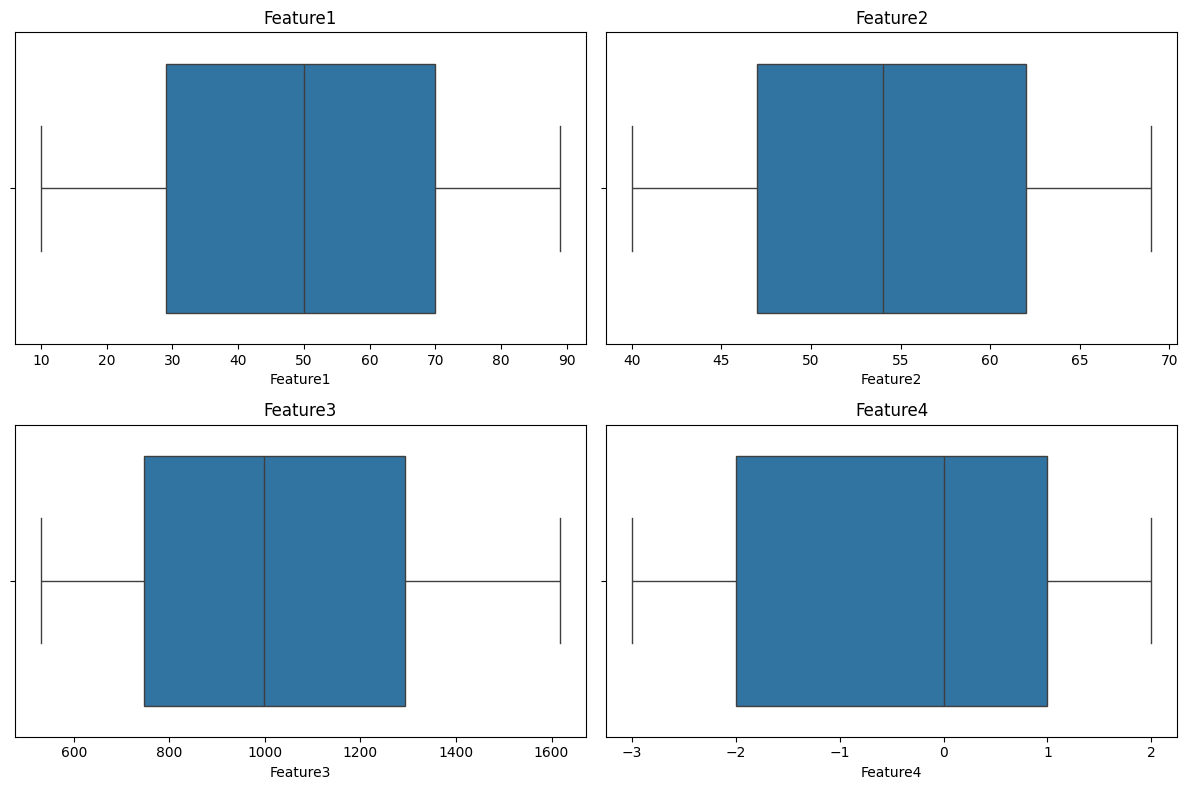

In [17]:
# Outlier Detection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows, 2 columns
axes = axes.flatten()

for i, col in enumerate(df.columns[:4]):  # first 4 columns
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

<Axes: >

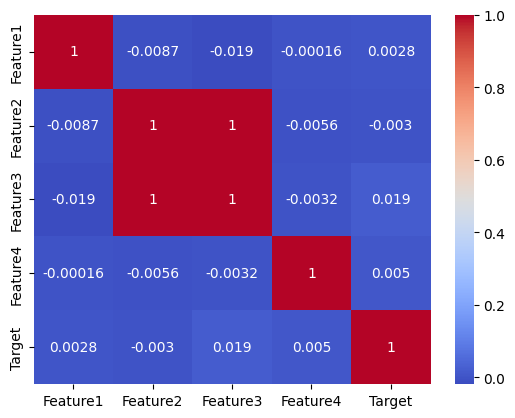

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

### 4. Data Preprocessing

In [19]:
X = df.drop('Target', axis=1)
y = df['Target']

In [20]:
X.isnull().sum()

Feature1    0
Feature2    0
Feature3    0
Feature4    0
dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
X_scaled = scaler.fit_transform(X)

### 5. Machine Learning

In [24]:
from sklearn.model_selection import train_test_split

# Linear Models
from sklearn.linear_model import (
    LinearRegression,
    Lasso,        # L1 Regularization
    Ridge,        # L2 Regularization
    ElasticNet    # Elastic Net
)

# Support Vector Machine for Regression
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42)

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic Net": ElasticNet(),
    "SVR": SVR()
}

In [27]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

In [28]:
# Converting results into DataFrame(for more readability)
results_df = pd.DataFrame(results).T
results_df

,MAE,MSE,RMSE,R2
Linear Regression,16.533414,372.743767,19.306573,0.076866
Lasso,17.410034,403.796825,20.094696,-0.000040
Ridge,16.549620,372.603619,19.302943,0.077213
Elastic Net,17.410034,403.796825,20.094696,-0.000040
SVR,17.328666,399.048294,19.976193,0.011720


#### Upvote me it you like my work :)